In [46]:
import numpy as np
from itertools import combinations, combinations_with_replacement
import scipy
import matplotlib.pyplot as plt

from qokit.utils import brute_force
from qokit import get_qaoa_objective

In [72]:
data = np.load('../out/tangle/qubo_data_test.npy', allow_pickle=True)
Q, offset, W = data
# Move terms to upper triangular part
Q = np.triu(Q) * 2
Q -= np.triu(np.triu(Q).T) / 2
N_vars = Q.shape[0]

# Get Hamiltonian terms
terms = [(Q[i, j], [i, j]) for i in range(N_vars) for j in range(i, N_vars)]

In [64]:
# Small test
N_vars = 10
np.random.seed(100)
terms = [(np.random.normal(), spin_pair) for spin_pair in combinations_with_replacement(range(N_vars), r=2)]

In [73]:
# Get objective
p = 5
f = get_qaoa_objective(N_vars, p, terms=terms, parameterization='theta')

KeyboardInterrupt: 

In [66]:
initial_gamma = -1*np.linspace(0, 1, p)
initial_beta = np.linspace(1, 0, p)

res = scipy.optimize.minimize(f, np.hstack([initial_gamma, initial_beta]), method='COBYLA', options={'rhobeg': 0.01})

In [67]:
print(f"Expected QAOA solution quality: {res.fun:.5f}")

Expected QAOA solution quality: -17.56075


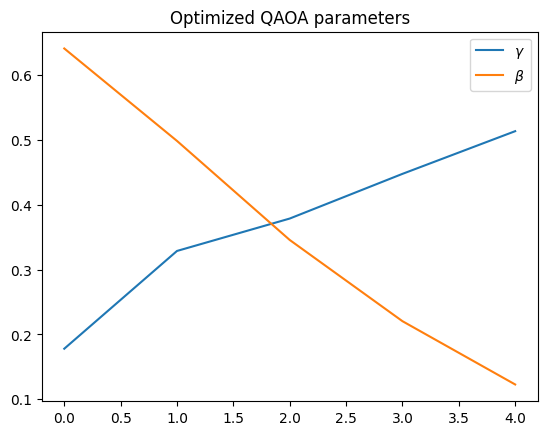

In [68]:
plt.plot(-res.x[:p], label=r"$\gamma$")
plt.plot(res.x[p:], label=r"$\beta$")
plt.title('Optimized QAOA parameters')
plt.legend()

In [69]:
def f_from_terms_ground_truth(s):
    """ground truth for debugging
    """
    out = 0
    for coeff, (i, j) in terms:
        out += coeff * s[i] * s[j]
    return out

In [70]:
print(f"True minimum: {brute_force(f_from_terms_ground_truth, N_vars, minimize=True)[0]:.5f}")

True minimum: -20.18009
